In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

train_data = pd.read_csv(r'student_performance_preprocessed_train.csv')
test_data = pd.read_csv(r'student_performance_preprocessed_test.csv')

print("Columns:", train_data.columns.tolist())
print("\nTrain Data Head:")
print(train_data.head())

Columns: ['Study_Hours', 'Attendance_Percentage', 'Assignment_Score', 'Quiz_Score', 'Project_Score', 'Midterm_Exam', 'Course_Work_Score', 'Final_Exam_Score', 'Status']

Train Data Head:
   Study_Hours  Attendance_Percentage  Assignment_Score  Quiz_Score  \
0     0.163636               1.031496         -0.793605   -0.185539   
1    -0.109091              -0.653543         -1.154070   -0.442019   
2    -0.127273              -0.637795         -0.886628   -0.387449   
3    -0.109091               0.818898          0.316860    0.616644   
4     1.727273               0.763780          1.456395    1.162347   

   Project_Score  Midterm_Exam  Course_Work_Score  Final_Exam_Score Status  
0      -0.217647     -0.115385          -0.405229         -0.336283   Fail  
1      -0.611765     -0.168269          -0.790850          0.053097   Fail  
2      -0.394118      0.168269          -0.588235         -0.252212   Fail  
3       0.605882      1.033654           0.627451         -0.238938   Pass  
4 

In [3]:

feature_columns = [
    'Study_Hours',
    'Attendance_Percentage', 
    'Assignment_Score',
    'Quiz_Score',
    'Project_Score',
    'Midterm_Exam'
]

X_train = train_data[feature_columns]  
y_train = train_data['Status']  

# فصل Test
X_test = test_data[feature_columns]  
y_test = test_data['Status']  

print("X_train shape:", X_train.shape)  
print("y_train shape:", y_train.shape) 
print("\nX_test shape:", X_test.shape)   
print("y_test shape:", y_test.shape)   

X_train shape: (8000, 6)
y_train shape: (8000,)

X_test shape: (2000, 6)
y_test shape: (2000,)


In [4]:

y_train_binary = (y_train == 'Pass').astype(int)
y_test_binary = (y_test == 'Pass').astype(int)

print("\nTrain Distribution:")
print(y_train_binary.value_counts())
print("\nTest Distribution:")
print(y_test_binary.value_counts())


Train Distribution:
Status
1    4367
0    3633
Name: count, dtype: int64

Test Distribution:
Status
1    1092
0     908
Name: count, dtype: int64


In [5]:

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [6]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train_binary)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test_scaled)


In [8]:
# Evaluation
print(classification_report(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.92       908
           1       0.93      0.94      0.94      1092

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



<Axes: >

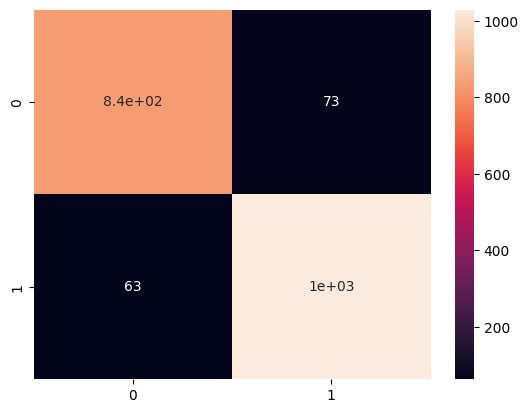

In [9]:
cm=confusion_matrix(y_test_binary, y_pred)
sns.heatmap(cm,annot=True)

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import accuracy_score, f1_score

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  SVM
svm_rbf = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

# Train
svm_rbf.fit(X_train_scaled, y_train_binary)

# Predict
pred_rbf = svm_rbf.predict(X_test_scaled)

# Accuracy
print("\nAccuracy:")
print(accuracy_score(y_test_binary, pred_rbf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_binary, pred_rbf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_binary, pred_rbf))


Accuracy:
0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92       908
           1       0.93      0.94      0.94      1092

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000


Confusion Matrix:
[[ 836   72]
 [  68 1024]]


In [12]:
svm_linear = SVC(
    kernel="linear",
    C=1.0
)

svm_linear.fit(X_train_scaled, y_train_binary)

pred_linear = svm_linear.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test_binary, pred_linear), 4))

print("F1 Score:", round(f1_score(y_test_binary, pred_linear), 4))

Accuracy: 0.9325
F1 Score: 0.9384


polynomial very bad predict bias to class 1

In [13]:
svm_poly = SVC(
    kernel="poly",
    C=1.0,
    degree=2,
    gamma="scale"
)

svm_poly.fit(X_train_scaled, y_train_binary)

pred_poly = svm_poly.predict(X_test_scaled)

print("Accuracy:", round(accuracy_score(y_test_binary, pred_poly), 4))

print("F1 Score:", round(f1_score(y_test_binary, pred_poly), 4))

Accuracy: 0.5755
F1 Score: 0.5398


In [14]:
print(classification_report(y_test_binary, pred_poly))

              precision    recall  f1-score   support

           0       0.52      0.72      0.61       908
           1       0.66      0.46      0.54      1092

    accuracy                           0.58      2000
   macro avg       0.59      0.59      0.57      2000
weighted avg       0.60      0.58      0.57      2000

